Before running code, type into terminal:
    
    python –m venv venv\ 
^this creates the virtual enviornment

    venv\Scripts\activate
^this activates the virtual environment

    python -m pip install -r requirements.txt
^this installs packages according to the requirements.txt file

Notes from Meghan on how to use this code:
1. I have found that I need to open this code from a folder using the file explorer (as G demonstrated in her crash course VSCode video), changing the working directory in the terminal has not worked for me. I think there is a fairly high chance I am doing something wrong, but if others run into an issue where file names below like 'EditedFunctions251226mr' are in white instead of blue and not running with the error 'import could not be resolved', I have been able to solve that by closing VSCode and re-opening the folder from the file explorer.
2. Don't import the phydrus package. The EditedFunctions251226mr, ProfileFunction, and PlottingFunctions take its place, and are edited to allow different root growth approaches. It seems to be okay that phydrus is included in the requirements text file, as long as phydrus is not actually imported.
3. This code allows for a roots input file where root depths are specified for each month. The code then assigns each day a rooting depth based on what month it is. This exact approach can definetly be refined. This script includes 2 different root growth input files as examples.

In [2]:
#Importing phydrus
import os

#import phydrus as ps #this works for Meghan using version 0.2.0

from EditedFunctions260112mr import Model #Meghan's edits for roots

import ProfileFunction as pl #Profile function from GitHub

import PlottingFunctions as Plots #Plotting function from GitHub

import pandas as pd #this works for Meghan using version 2.3.3

import numpy as np #this works for Meghan using version 2.3.5

import matplotlib.pyplot as plt #this works for Meghan using version 3.10.7

import datetime



In [3]:
#Doing working directory stuff

#set working directory manually (I'm sure there is a better way to do this)
#os.chdir('C:\\Users\\meghanrobinson\\Downloads\\Modeling\\PHydrusTest\\PipelineStructure')

#give path to exe file
exe = os.path.join(os.getcwd(), "H1D_Dual.exe")

#name the folder files will fill
main_level = os.path.normpath(os.path.join(os.getcwd(), os.pardir))

In [4]:
atm = pd.read_csv(os.path.join(main_level, '1_Input', 'WeatherData.csv'))
days = len(atm['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', 'IrrigationData.csv'))
cropdates = pd.read_csv(os.path.join(main_level, '1_Input', 'CropSeedHarvestDates.csv'))
gddinfo = pd.read_csv(os.path.join(main_level, '1_Input', 'GDD_CropGrowth_Relationship.csv'))
roots = pd.read_csv(os.path.join(main_level, '1_Input', 'RootsObserved_24-10-25_mr.csv'))
gddinfo

,crop,seed.date,gdd2emergence,gdd2close,gdd2mature,gdd2harvest,max.coef,root.depth.max
0,W.Wheat,10/1/2016,140,500,1600,1730,0.75,107
1,S.Wheat,4/17/2016,170,800,1500,2200,1.20,81
2,Barley,5/1/2016,150,400,1400,1900,1.20,70
3,Corn,4/17/2016,170,800,1500,2200,0.70,50
4,Soybean,4/17/2016,170,800,1500,2200,1.50,180
5,Alfalfa,4/17/2016,1,2,3,300000,1.20,81
6,Potato,4/17/2016,300,900,1500,2000,0.95,90
7,Fallow,1/1/2016,0,0,0,0,0.22,0


In [5]:
def add_gdds(weatherdata, cropdates):
    weatherdata['gdds']=0
    weatherdata['Year']= "NA"

    for i in range(len(weatherdata)):
        weatherdata['Year'][i] = weatherdata.iloc[i].Date[:4]

    weatherdata['Year'] = weatherdata['Year'].astype(int)

    weatherdata = weatherdata.merge(cropdates, on= "Year").rename(columns={'Seeding': 'StartDate','Harvest': 'EndDate'})
    weatherdata['StartDate'] = pd.to_datetime(weatherdata['StartDate'])
    weatherdata['EndDate'] = pd.to_datetime(weatherdata['EndDate'])
    weatherdata['Date'] = pd.to_datetime(weatherdata['Date'])

    for i in range(1,len(weatherdata)):
        if (weatherdata['Date'][i] >= weatherdata['StartDate'][i] and weatherdata['Date'][i] <= weatherdata['EndDate'][i] and weatherdata['AvgTemp'][i] > 0):
            weatherdata['gdds'][i] = weatherdata['gdds'][i-1] + weatherdata['AvgTemp'][i-1]
    
    return weatherdata

def partition_et(weatherdata, gddinfo):
    
    fallow_coef = gddinfo.loc[gddinfo['crop'] == 'Fallow']['max.coef']

    weatherdata['t_coef'] = 0
    weatherdata['e_coef'] = 0.22
  
    for i in range(len(weatherdata)):
        crop = weatherdata['Crop'][i]
        max_coef = gddinfo.loc[gddinfo['crop'] == crop]['max.coef']
        
        check1 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']).astype(int))
        check1 = all(check1)

        if check1 == True:
            weatherdata['t_coef'][i] = (weatherdata['gdds'][i] - gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence'])*max_coef/(gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']-gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence'])

        check2 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature']).astype(int))
        check2 = all(check2)

        if check2 == True:
            weatherdata['t_coef'][i] = max_coef
        
        check3 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2harvest']).astype(int))
        check3 = all(check3)

        if check3 == True:
            weatherdata['t_coef'][i] = max_coef-(weatherdata['gdds'][i] - gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature'])/(gddinfo.loc[gddinfo['crop'] == crop]['gdd2harvest']-gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature'])

        check4 = weatherdata['t_coef'][i] <= 0.22
        check4 = bool(check4)

        if check4 == True:
            weatherdata['e_coef'][i] = fallow_coef - weatherdata['t_coef'][i]

        check5 = weatherdata['t_coef'][i] > 0.22
        check5 = bool(check5)
        if check5 == True:
            weatherdata['e_coef'][i] = 0

        weatherdata['pot_t_cm'] = weatherdata['ET_cm']*weatherdata['t_coef']
        weatherdata['pot_e_cm'] = weatherdata['ET_cm']*weatherdata['e_coef']

    return(weatherdata)

def grow_roots_obs(weatherdata, rootobs):
    rootobs['Date'] = pd.to_datetime(rootobs['Date'])
    atmtest= weatherdata
    atmtest['RootDepth'] = 0
    atmtest = atmtest.merge(rootobs, how= 'left', on= 'Date')
    atmtest.loc[np.isnan(atmtest['Depth']) == False, 'RootDepth'] = atmtest.loc[np.isnan(atmtest['Depth']) == False, 'Depth']

    years = list(set(atmtest['Year']))

    for k in range(len(years)):
        
        root_year = atmtest.loc[(atmtest['Year'] == years[k]) & (np.isnan(atmtest['Depth']) == False)]

        rts = {'Growthrate': ["NA"], 'Day1': ["NA"], 'Day2': ["NA"]}
        allroots = pd.DataFrame(rts)

        for i in range(1, len(root_year)):
            growth = root_year.iloc[i]['Depth'] - root_year.iloc[i-1]['Depth']
            time = root_year.iloc[i]['Date'] - root_year.iloc[i-1]['Date']
            time= time.days
            growthrate = growth/time
            day1 = root_year.iloc[i-1]['Date']
            day2 = root_year.iloc[i]['Date']

            minidata = pd.DataFrame({'Growthrate':[growthrate], 'Day1':[day1], 'Day2':[day2]})
            allroots = pd.concat([allroots, minidata], ignore_index=True)

        allroots = allroots[allroots['Growthrate'] != "NA"]
        allroots.loc[allroots['Growthrate'] <  0, 'Growthrate'] = 0

        for i in range(len(allroots)):
            day1 = allroots.iloc[i]['Day1']
            day2 = allroots.iloc[i]['Day2']
            gr = allroots.iloc[i]['Growthrate']

            for j in range(len(atmtest)):
                if (atmtest.iloc[j]['Date'] > day1) & (atmtest.iloc[j]['Date'] < day2):
                    atmtest['RootDepth'][j] = atmtest['RootDepth'][j-1] + gr
    return(atmtest)

def grow_roots_gdd(weatherdata, cropdata):
    atmtest = weatherdata
    atmtest['RootDepth'] = 0

    for i in range(1,len(atmtest)):
        crop = atmtest['Crop'][i]
        max_depth = cropdata.loc[cropdata['crop'] == crop, 'root.depth.max']
        max_depth

        check1 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1 = all(check1)
        if check1 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] + (atmtest['AvgTemp'][i] * 0.0665)

        check1b = (atmtest.iloc[i]['AvgTemp'] < 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1b = all(check1b)
        if check1b == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check2 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] >= max_depth)
        check2 = all(check2)
        if check2 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check3 = (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['EndDate'])
        if check3 == True:
            atmtest['RootDepth'][i] = 0

    return(atmtest)
    

In [6]:
atm2 = add_gdds(weatherdata=atm, cropdates=cropdates)
atm3 = partition_et(weatherdata= atm2, gddinfo=gddinfo)
atm4a = grow_roots_obs(weatherdata= atm3, rootobs= roots)
atm4b = grow_roots_gdd(weatherdata= atm3, cropdata=gddinfo)

C:\Users\meghanrobinson\AppData\Local\Temp\ipykernel_20228\3431115557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weatherdata['Year'][i] = weatherdata.iloc[i].Date[:4]
C:\Users\meghanrobinson\AppData\Local\Temp\ipykernel_20228\3431115557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weatherdata['Year'][i] = weatherdata.iloc[i].Date[:4]
C:\Users\meghanrobinson\AppData\Local\Temp\ipykernel_20228\3431115557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

# Load Data

In [9]:
#read in csvs

#Atmospheric Input
days = len(atm4a['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', 'IrrigationData.csv'))
irrigation['Date'] = pd.to_datetime(irrigation['Date'])

#merge weather and irrigation and add for a total water input column
allatm = atm4a.join(irrigation.set_index('Date'), on='Date')
allatm.loc[np.isnan(allatm['Amount_cm']) == True, 'Amount_cm'] = 0
allatm['WaterIn_cm'] = allatm['Precip'] + allatm['Amount_cm']

#create new dataframe to manipulate to be exactly what is needed for PHydrus (keeping old version w/ temperature info for now)
atm_hydrus = allatm[['WaterIn_cm', 'pot_e_cm', 'pot_t_cm', 'Depth']]

#these are required column names: 'tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT'
atm_hydrus = atm_hydrus.rename(columns={'pot_e_cm':'rSoil', 'WaterIn_cm':'Prec', 'pot_t_cm': 'rRoot'}) #rename columns that are there
atm_hydrus['tAtm'] = range(1,len(atm2)+1)
atm_hydrus['hCritA']= 1000000 #max allowed surface head, this is hydrus default
atm_hydrus['rB']= 0 #bottom flux, is zero for free drainage boundary condition
atm_hydrus['hB']= 0 #groundwater level, is zero if model is not being run with groundwater
atm_hydrus['hT']= 0 #surface pressure head, zero if model uses free drainage

#rearrange to match format input
atm_hydrus = atm_hydrus[['tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT']]

#Van Genuchten parameters
vgs = pd.read_csv(os.path.join(main_level, '1_Input', 'VGParamsDP.csv'))
vgs_1= vgs.iloc[0, 2:19] #take one row 
vgs_2= vgs.iloc[1, 2:19] #take another row 
vgs_3= vgs.iloc[2, 2:19]
vglist1= list(vgs_1)
vglist2= list(vgs_2)
vglist3= list(vgs_3)

#Observation Nodes
obs = pd.read_csv(os.path.join(main_level, '1_Input', 'ObservationInput.csv'))
obspts = obs.iloc[:, 2]
obspts= obspts*-1
obslist = list(obspts)

#Timestep list 
timesteps = [0.4] #one that intentionally doesn't work to test
timesteps2 = [0.4, 0.001, 0.003, 0.005, 0.006, 0.0001, 0.0003, 0.0004, 0.01, 0.00002,
             0.00003, 0.00004, 0.00005, 0.00006, 0.00007, 0.00009, 0.0002, 0.0007, 0.0009,
             0.0055, 0.0065, 0.00015, 0.00055, 0.00095] #actual good time steps
atm_hydrus


,tAtm,Prec,rSoil,rRoot,hCritA,rB,hB,hT
0,1,0.0000,0.015646,0.0,1000000,0,0,0
1,2,0.0000,0.007823,0.0,1000000,0,0,0
2,3,0.0000,0.023470,0.0,1000000,0,0,0
3,4,0.0000,0.016764,0.0,1000000,0,0,0
4,5,0.0000,0.007264,0.0,1000000,0,0,0
...,...,...,...,...,...,...,...,...
751,752,0.0000,0.032969,0.0,1000000,0,0,0
752,753,0.0000,0.010058,0.0,1000000,0,0,0
753,754,0.0000,0.034087,0.0,1000000,0,0,0
754,755,0.0663,0.006147,0.0,1000000,0,0,0


In [8]:
allatm

,Date,Precip,ET_cm,MinTemp,MaxTemp,AvgTemp,gdds,Year,StartDate,EndDate,Crop,t_coef,e_coef,pot_t_cm,pot_e_cm,RootDepth,Depth,Amount_in,Amount_cm,WaterIn_cm
0,2023-01-01,0.0000,0.07112,-6.275,4.775,-1.264583,0.0,2023,2023-05-16,2023-08-26,Barley,0.0,0.22,0.0,0.015646,0.0,NaN,NaN,0.0,0.0000
1,2023-01-02,0.0000,0.03556,-9.800,2.450,-4.713542,0.0,2023,2023-05-16,2023-08-26,Barley,0.0,0.22,0.0,0.007823,0.0,NaN,NaN,0.0,0.0000
2,2023-01-03,0.0000,0.10668,-8.450,2.175,-3.865625,0.0,2023,2023-05-16,2023-08-26,Barley,0.0,0.22,0.0,0.023470,0.0,NaN,NaN,0.0,0.0000
3,2023-01-04,0.0000,0.07620,-7.550,4.150,-2.598958,0.0,2023,2023-05-16,2023-08-26,Barley,0.0,0.22,0.0,0.016764,0.0,NaN,NaN,0.0,0.0000
4,2023-01-05,0.0000,0.03302,-11.300,1.750,-4.666667,0.0,2023,2023-05-16,2023-08-26,Barley,0.0,0.22,0.0,0.007264,0.0,NaN,NaN,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,2025-01-21,0.0000,0.14986,-6.725,0.800,-3.219792,0.0,2025,2025-05-01,2025-08-25,Barley,0.0,0.22,0.0,0.032969,0.0,NaN,NaN,0.0,0.0000
752,2025-01-22,0.0000,0.04572,-12.475,-1.400,-5.309375,0.0,2025,2025-05-01,2025-08-25,Barley,0.0,0.22,0.0,0.010058,0.0,NaN,NaN,0.0,0.0000
753,2025-01-23,0.0000,0.15494,-9.200,1.875,-2.871875,0.0,2025,2025-05-01,2025-08-25,Barley,0.0,0.22,0.0,0.034087,0.0,NaN,NaN,0.0,0.0000
754,2025-01-24,0.0663,0.02794,-8.500,-0.275,-4.252083,0.0,2025,2025-05-01,2025-08-25,Barley,0.0,0.22,0.0,0.006147,0.0,NaN,NaN,0.0,0.0663


# Dual Permeability 

In [ ]:
#Model Run For Dual Permeability: trying with one set of DP parameters
newfolder = 'DualPermTest3_ET'
ws = os.path.join(main_level, '3_Results', newfolder)

#loop iterating through time steps

for i in range(len(timesteps2)):
    #basic model info (name, units)
    ml = Model(exe_name=exe, #telling it to use single porosity exe
              ws_name=ws, #folder to create/fill (in 3_Results)
              name="model",
              mass_units="mmol", time_unit="days", length_unit="cm")
    
    #add time info
    times = ml.add_time_info(tinit=0, #first day
                         tmax=days, #last day
                         print_times=True, #true if want model to print t level info every day
                        # printinit= 1,
                         #printmax= 40,
                         #dtprint= 1,
                         dt=timesteps2[i], #initial time increment (this is what R iteratres through)
                         dtmax=0.5, #max time increment (didn't change)
                         #printinit=120 #this would specify when to start printing t level info
                        )
    
    #add waterflow information for selector on model type, boundary conditions, can add groundwater here (didn't)
    ml.add_waterflow(model= 9, #dual permeability
                 top_bc=3, #top boundary condition is atmospheric with runoff
                 bot_bc=4, #bottom boundary condition is free drainage
                 )
    
    #this is a dataframe for soil materials, n=1 is number of materials
    m = ml.get_empty_material_df_modified(n=1)
    
    #these are vg parameters for each depth
    m.loc[1] = vglist1
    

    #add materials to function
    ml.add_material(m)
    
    #create soil profile
    profile = pl.create_profile(bot= -150, #depth of soil profile
                                dx= 1, #grid cells 1 cm
                                h=-15 #intial pressure head
                                )
    
   # profile.loc[75:100, "Mat"] = 2 #depth to start second soil material
    
        #add  profile to model
    ml.add_profile_modified(profile, qtop= 0.1) #qtop is the water going into cracks vs normal soil, 0-1 range, this means 10% entering cracks
    
    #observations nodes
    ml.add_obs_nodes(obslist)
    
    poptms= [-1]
    ml.add_root_uptake(model= 0, #feddes water uptake
                   p0= -1, #pressure head below which roots can extract water from soil
                   p2h= -500, #pressure head below which roots cannot extract water at maximum rate
                   p2l= -900, #manual says same as p2h exceot with potential transpiration of 'r2L'
                   p3= -1600, #wilting point: no root water extraction
                   r2h= 0.5,
                   r2l= 0.1,
                   poptm= poptms, #pressure head below which roots extract water at max rate, 1 per soil type
                   pexp= 3, #exponent for stress response function, accepting default of 3
                   crootmax= 1 #this is max concentration of solute for root uptake, this model doesn't have solutes but isn't working without
                   )
    
    #make table of root data
    
    '''
    ml.add_root_growth(irootin= 1, #roots are a table
                       ngrowth= len(atm2), #number of data points
                       tgrowth= atm2['tAtm'], #days
                       rootdepth= atm2['RootDepth'] #root depths
                       )
  
    '''
    ml.add_root_growth(irootin= 2, #this has to be 2 for dual permeability
                       irfak= 0, #root growth is calculated from given data
                       trmin= 1, #day when roots start growing
                       trmed= 150, #time of a specific root growth benchmark
                       trmax= 365, #end of root growth period
                       xrmin= 20, #root depth at start of growth period
                       xrmed= 25, #root depth at trmed time
                       xrmax= 30, #max rooting depth
                       trperiod= 365 #number of days in root growth cycle
                       )
 
    #add atmosphere input to Hydrus
    ml.add_atmospheric_bc(atm_hydrus,
                          hcrits=0)
    
    #write out input files
    ml.write_input_modified()
    
    #run Hydrus!
    rs = ml.simulate()

    #check if model ran completely
    #first step: read in output
    tlevel = ml.read_tlevel_modified()

    #check that output length equals input length, if TRUE stop loop, if FALSE keep going
    if len(tlevel) == days:
       # ml.plots.profile()
        break
    else:
        if i == len(timesteps2)-1:
            failed = pd.DataFrame()
            failed.to_csv(os.path.join(main_level, '3_Results', newfolder, 'FAILED.csv'))


c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\EditedFunctions260112mr.py:504: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 4.2670e-01
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 6.8000e-02 3.2300e-02 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 6.1200e-02 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 2.3290e-01 1.7660e-01 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 2.4650e-01 0.0000e+00
 0.0000e+00 0.00

c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:198: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = read_csv(file, skiprows=s, nrows=e - s - 2, usecols=usecols,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:203: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.drop(index=data.index[0]).apply(to_numeric,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:243: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1

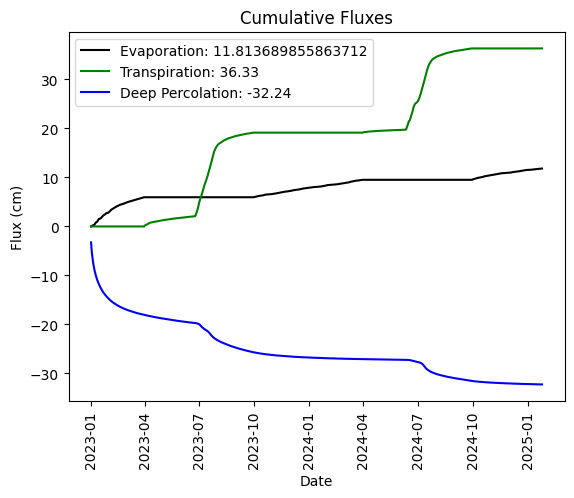

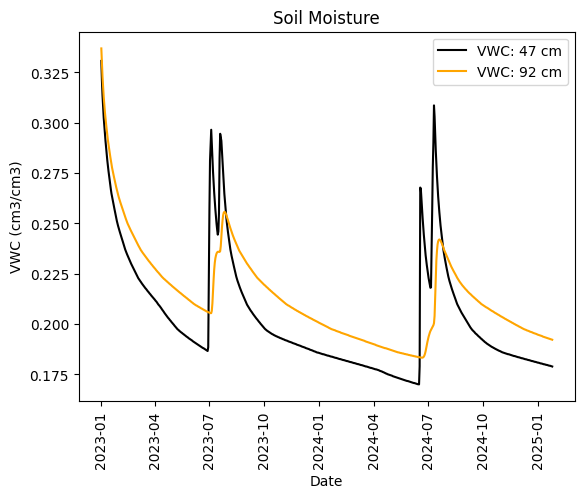

In [ ]:
#Read in data and plot for Run 1
if ("FAILED.csv" in os.listdir(os.path.join(main_level, '3_Results', newfolder))) == False:
    
    #read in t level and obs node data
    tlevel = ml.read_tlevel_modified(usecols= ['Time','rTopT', 'rRootT', 'vTopT', 'vRootT', 'vBotT', 'sum(rTopT)', 'sum(rRoot)', 'sum(vTopT)',
'sum(vRoot)', 'sum(vBotT)', 'hTop', 'hRoot', 'hBot', 'vTopF', 'vTopM', 'sum(vTopM)', 'vFrac', 'sum(vFrac)', 'vBotF', 'sum(vBotF)', 'vBotM', 'sum(vBotM)'])
    obsnode = ml.read_obs_node()

    #make obs node data into a dataframe
    allobs = pd.DataFrame()
    
    for i in range(len(obslist)):
       nodenum = obslist[i]*-1+1
       obstemp =obsnode[nodenum]
       obstemp= obstemp.rename(columns={'h':f"h{nodenum}",
                             'theta':f"theta{nodenum}",
                             'Temp':f"temp{nodenum}"})
       allobs = pd.concat([allobs, obstemp], axis=1)

    #merge data to create csv file
    output = pd.concat([tlevel, allobs], axis=1)
    outputr = output.reset_index(drop=True)
    alldata = pd.concat([atm, outputr], axis= 1)


    alldata.to_csv(os.path.join(main_level, '3_Results', newfolder, 'HydrusMergedData.csv'))
    
    #make a new folder for plots to fill
    if not os.path.exists(os.path.join(main_level, '3_Results', newfolder, 'Plots')):
        os.mkdir(os.path.join(main_level, '3_Results', newfolder, 'Plots'))

    alldata['DailyEvap'] = alldata['vTopT']
    alldata['sum(Evap)'] = 0

    for i in range(1,len(alldata['Date'])):
        if bool(alldata['DailyEvap'][i] < -0.01) == True:
            alldata['DailyEvap'][i]= 0
        
        alldata['sum(Evap)'][i] = alldata['sum(Evap)'][i-1] + alldata['DailyEvap'][i]

    #plot cumulative fluxes
    xs= alldata['Date']
    
    from datetime import datetime
    xs = pd.to_datetime(xs)
    y1 = alldata['sum(Evap)']
    y3= alldata['sum(vRoot)']
    y4= alldata['sum(vBotT)']
    
    #get maxes to include on plot
    emax = max(alldata['sum(Evap)'])
    tmax = max(alldata['sum(vRoot)'])
    dmax = min(alldata['sum(vBotT)'])
    
    #plt.plot(xs, y1, xs, y2, xs, y3, xs, y4)
    plt.plot(xs, y1, label= f"Evaporation: {emax}", c= "black")
    plt.plot(xs, y3, label= f"Transpiration: {tmax}", c= "green")
    plt.plot(xs, y4, label= f"Deep Percolation: {dmax}", c= "blue")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Flux (cm)")
    plt.title("Cumulative Fluxes")
    plt.xticks(rotation= 90)
    
    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'CumulativeFluxes.png'))
    plt.show()
    #plot soil moisture at specified depths
    y1 = alldata['theta47']
    y2= alldata['theta92']
    
    plt.plot(xs, y1, label= "VWC: 47 cm", c= "black")
    plt.plot(xs, y2, label= "VWC: 92 cm", c= "orange")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("VWC (cm3/cm3)")
    plt.title("Soil Moisture")
    plt.xticks(rotation= 90)

    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'SoilMoisture.png'))
    plt.show()
    



In [61]:
#Model Run For Dual Permeability with new set of parameters
newfolder = 'DualPermTest2'
ws = os.path.join(main_level, '3_Results', newfolder)

#loop iterating through time steps

for i in range(len(timesteps2)):
    #basic model info (name, units)
    ml = Model(exe_name=exe, #telling it to use single porosity exe
              ws_name=ws, #folder to create/fill (in 3_Results)
              name="model",
              mass_units="mmol", time_unit="days", length_unit="cm")
    
    #add time info
    times = ml.add_time_info(tinit=0, #first day
                         tmax=days, #last day
                         print_times=True, #true if want model to print t level info every day
                        # printinit= 1,
                         #printmax= 40,
                         #dtprint= 1,
                         dt=timesteps2[i], #initial time increment (this is what R iteratres through)
                         dtmax=0.5, #max time increment (didn't change)
                         #printinit=120 #this would specify when to start printing t level info
                        )
    
    #add waterflow information for selector on model type, boundary conditions, can add groundwater here (didn't)
    ml.add_waterflow(model= 9, #single porosity
                 top_bc=3, #top boundary condition is atmospheric with runoff
                 bot_bc=4, #bottom boundary condition is free drainage
                 )
    
    #this is a dataframe for soil materials, n=1 is number of materials
    m = ml.get_empty_material_df_modified(n=1)
    
    #these are vg parameters for each depth
    vgs2 = np.array(vglist2)
    m.loc[1] = vgs2
    

    #add materials to function
    ml.add_material(m)
    
    #create soil profile
    profile = pl.create_profile(bot= -150, #depth of soil profile
                                dx= 1, #grid cells 1 cm
                                h=-15 #intial pressure head
                                )
    
   # profile.loc[75:100, "Mat"] = 2 #depth to start second soil material
    
        #add  profile to model
    ml.add_profile_modified(profile, qtop= 0.1)
    
    #observations nodes
    ml.add_obs_nodes(obslist)
    
    poptms= [-1]
    ml.add_root_uptake(model= 0, #feddes water uptake
                   p0= -1, #pressure head below which roots can extract water from soil
                   p2h= -500, #pressure head below which roots cannot extract water at maximum rate
                   p2l= -900, #manual says same as p2h exceot with potential transpiration of 'r2L'
                   p3= -1600, #wilting point: no root water extraction
                   r2h= 0.5,
                   r2l= 0.1,
                   poptm= poptms, #pressure head below which roots extract water at max rate, 1 per soil type
                   pexp= 3, #exponent for stress response function, accepting default of 3
                   crootmax= 1 #this is max concentration of solute for root uptake, this model doesn't have solutes but isn't working without
                   )
    
    #make table of root data
    
    '''
    ml.add_root_growth(irootin= 1, #roots are a table
                       ngrowth= len(atm2), #number of data points
                       tgrowth= atm2['tAtm'], #days
                       rootdepth= atm2['RootDepth'] #root depths
                       )
  
    '''
    ml.add_root_growth(irootin= 2,
                       irfak= 0, #root growth is calculated from given data
                       trmin= 1, #day when roots start growing
                       trmed= 150, #time of a specific root growth benchmark
                       trmax= 365, #end of root growth period
                       xrmin= 20, #root depth at start of growth period
                       xrmed= 25, #root depth at trmed time
                       xrmax= 30, #max rooting depth
                       trperiod= 365 #number of days in root growth cycle
                       )
 
    #add atmosphere input to Hydrus
    ml.add_atmospheric_bc(atm2,
                          hcrits=0)
    
    #write out input files
    ml.write_input_modified()
    
    #run Hydrus!
    rs = ml.simulate()

    #check if model ran completely
    #first step: read in output
    tlevel = ml.read_tlevel_modified()

    #check that output length equals input length, if TRUE stop loop, if FALSE keep going
    if len(tlevel) == days:
       # ml.plots.profile()
        break
    else:
        if i == len(timesteps2)-1:
            failed = pd.DataFrame()
            failed.to_csv(os.path.join(main_level, '3_Results', newfolder, 'FAILED.csv'))


c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\EditedFunctions260112mr.py:504: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0

c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:198: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = read_csv(file, skiprows=s, nrows=e - s - 2, usecols=usecols,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:203: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.drop(index=data.index[0]).apply(to_numeric,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:243: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1

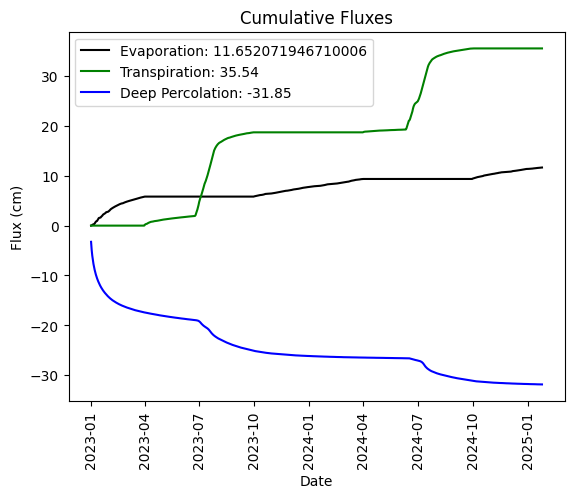

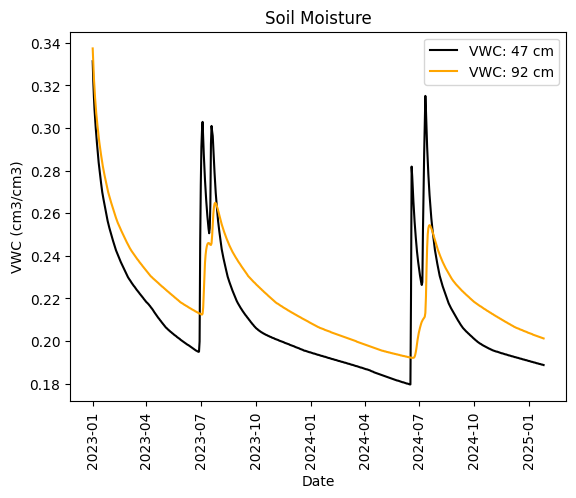

In [62]:
#Read in data and plot for Run 1
if ("FAILED.csv" in os.listdir(os.path.join(main_level, '3_Results', newfolder))) == False:
    
    #read in t level and obs node data
    tlevel = ml.read_tlevel_modified(usecols= ['Time','rTopT', 'rRootT', 'vTopT', 'vRootT', 'vBotT', 'sum(rTopT)', 'sum(rRoot)', 'sum(vTopT)',
'sum(vRoot)', 'sum(vBotT)', 'hTop', 'hRoot', 'hBot', 'vTopF', 'vTopM', 'sum(vTopM)', 'vFrac', 'sum(vFrac)', 'vBotF', 'sum(vBotF)', 'vBotM', 'sum(vBotM)'])
    obsnode = ml.read_obs_node()

    #make obs node data into a dataframe
    allobs = pd.DataFrame()
    
    for i in range(len(obslist)):
       nodenum = obslist[i]*-1+1
       obstemp =obsnode[nodenum]
       obstemp= obstemp.rename(columns={'h':f"h{nodenum}",
                             'theta':f"theta{nodenum}",
                             'Temp':f"temp{nodenum}"})
       allobs = pd.concat([allobs, obstemp], axis=1)

    #merge data to create csv file
    output = pd.concat([tlevel, allobs], axis=1)
    outputr = output.reset_index(drop=True)
    alldata = pd.concat([atm, outputr], axis= 1)


    alldata.to_csv(os.path.join(main_level, '3_Results', newfolder, 'HydrusMergedData.csv'))
    
    #make a new folder for plots to fill
    if not os.path.exists(os.path.join(main_level, '3_Results', newfolder, 'Plots')):
        os.mkdir(os.path.join(main_level, '3_Results', newfolder, 'Plots'))

    alldata['DailyEvap'] = alldata['vTopT']
    alldata['sum(Evap)'] = 0

    for i in range(1,len(alldata['Date'])):
        if bool(alldata['DailyEvap'][i] < -0.01) == True:
            alldata['DailyEvap'][i]= 0
        
        alldata['sum(Evap)'][i] = alldata['sum(Evap)'][i-1] + alldata['DailyEvap'][i]

    #plot cumulative fluxes
    xs= alldata['Date']
    
    from datetime import datetime
    xs = pd.to_datetime(xs)
    y1 = alldata['sum(Evap)']
    y3= alldata['sum(vRoot)']
    y4= alldata['sum(vBotT)']
    
    #get maxes to include on plot
    emax = max(alldata['sum(Evap)'])
    tmax = max(alldata['sum(vRoot)'])
    dmax = min(alldata['sum(vBotT)'])
    
    #plt.plot(xs, y1, xs, y2, xs, y3, xs, y4)
    plt.plot(xs, y1, label= f"Evaporation: {emax}", c= "black")
    plt.plot(xs, y3, label= f"Transpiration: {tmax}", c= "green")
    plt.plot(xs, y4, label= f"Deep Percolation: {dmax}", c= "blue")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Flux (cm)")
    plt.title("Cumulative Fluxes")
    plt.xticks(rotation= 90)
    
    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'CumulativeFluxes.png'))
    plt.show()
    #plot soil moisture at specified depths
    y1 = alldata['theta47']
    y2= alldata['theta92']
    
    plt.plot(xs, y1, label= "VWC: 47 cm", c= "black")
    plt.plot(xs, y2, label= "VWC: 92 cm", c= "orange")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("VWC (cm3/cm3)")
    plt.title("Soil Moisture")
    plt.xticks(rotation= 90)

    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'SoilMoisture.png'))
    plt.show()
    



# Daily Root Growth

In [ ]:
#Re-running with different root data, to make sure it works as expected
exe = os.path.join(os.getcwd(), "H1D_CALC.EXE")
newfolder = 'RootsObs'
ws = os.path.join(main_level, '3_Results', newfolder)

#Atmospheric Input
days = len(atm4a['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', 'IrrigationData.csv'))
irrigation['Date'] = pd.to_datetime(irrigation['Date'])

#merge weather and irrigation and add for a total water input column
allatm = atm4a.join(irrigation.set_index('Date'), on='Date')
allatm.loc[np.isnan(allatm['Amount_cm']) == True, 'Amount_cm'] = 0
allatm['WaterIn_cm'] = allatm['Precip'] + allatm['Amount_cm']

#create new dataframe to manipulate to be exactly what is needed for PHydrus (keeping old version w/ temperature info for now)
atm_hydrus = allatm[['WaterIn_cm', 'pot_e_cm', 'pot_t_cm', 'RootDepth']]

#these are required column names: 'tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT'
atm_hydrus = atm_hydrus.rename(columns={'pot_e_cm':'rSoil', 'WaterIn_cm':'Prec', 'pot_t_cm': 'rRoot'}) #rename columns that are there
atm_hydrus['tAtm'] = range(1,len(atm2)+1)
atm_hydrus['hCritA']= 1000000 #max allowed surface head, this is hydrus default
atm_hydrus['rB']= 0 #bottom flux, is zero for free drainage boundary condition
atm_hydrus['hB']= 0 #groundwater level, is zero if model is not being run with groundwater
atm_hydrus['hT']= 0 #surface pressure head, zero if model uses free drainage

#rearrange to match format input
atm_hydrus = atm_hydrus[['tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT', 'RootDepth']]
atm_hydrus.loc[np.isnan(atm_hydrus['RootDepth']) == True, 'RootDepth'] = 0

,tAtm,Prec,rSoil,rRoot,hCritA,rB,hB,hT,RootDepth
0,1,0.0000,0.015646,0.0,1000000,0,0,0,0.0
1,2,0.0000,0.007823,0.0,1000000,0,0,0,0.0
2,3,0.0000,0.023470,0.0,1000000,0,0,0,0.0
3,4,0.0000,0.016764,0.0,1000000,0,0,0,0.0
4,5,0.0000,0.007264,0.0,1000000,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...
751,752,0.0000,0.032969,0.0,1000000,0,0,0,0.0
752,753,0.0000,0.010058,0.0,1000000,0,0,0,0.0
753,754,0.0000,0.034087,0.0,1000000,0,0,0,0.0
754,755,0.0663,0.006147,0.0,1000000,0,0,0,0.0


In [11]:
#Run Hydrus with new inputs

for i in range(len(timesteps2)):
    #basic model info (name, units)
    ml = Model(exe_name=exe, #telling it to use single porosity exe
              ws_name=ws, #folder to create/fill (in 3_Results)
              name="model",
              mass_units="mmol", time_unit="days", length_unit="cm")
    #add time info
    times = ml.add_time_info(tinit=0, #first day
                         tmax=days, #last day
                         print_times=True, #true if want model to print t level info every day
                        # printinit= 1,
                         #printmax= 40,
                         #dtprint= 1,
                         dt=timesteps2[i], #initial time increment (this is what R iteratres through)
                         dtmax=0.5, #max time increment (didn't change)
                         #printinit=120 #this would specify when to start printing t level info
                        )
    
    #add waterflow information for selector on model type, boundary conditions, can add groundwater here (didn't)
    ml.add_waterflow(model= 0, #single porosity
                 top_bc=3, #top boundary condition is atmospheric with runoff
                 bot_bc=4, #bottom boundary condition is free drainage
                 )
    
    #this is a dataframe for soil materials, n=1 is number of materials
    m = ml.get_empty_material_df_modified(n=1)
    
    #these are vg parameters for each depth
    m.loc[1] = vglist1[0:6]
    

    #add materials to function
    ml.add_material(m)
    
    #create soil profile
    profile = pl.create_profile(bot= -150, #depth of soil profile
                                dx= 1, #grid cells 1 cm
                                h=-15 #intial pressure head
                                )
    
    #profile.loc[75:100, "Mat"] = 2 #depth to start second soil material
    #profile.loc[101:150, "Mat"] = 3
        #add  profile to model
    ml.add_profile_modified(profile)
    
    #observations nodes
    ml.add_obs_nodes(obslist)
    
    poptms= [-1]
    ml.add_root_uptake(model= 0, #feddes water uptake
                   p0= -1, #pressure head below which roots can extract water from soil
                   p2h= -500, #pressure head below which roots cannot extract water at maximum rate
                   p2l= -900, #manual says same as p2h exceot with potential transpiration of 'r2L'
                   p3= -1600, #wilting point: no root water extraction
                   r2h= 0.5,
                   r2l= 0.1,
                   poptm= poptms, #pressure head below which roots extract water at max rate, 1 per soil type
                   pexp= 3, #exponent for stress response function, accepting default of 3
                   crootmax= 1 #this is max concentration of solute for root uptake, this model doesn't have solutes but isn't working without
                   )
    
    #make table of root data
    ml.add_root_growth(irootin= 1, #roots are a table
                       ngrowth= len(atm_hydrus), #number of data points
                       tgrowth= atm_hydrus['tAtm'], #days
                       rootdepth= atm_hydrus['RootDepth'] #root depths
                       )
  
    '''
    ml.add_root_growth(irootin= 2,
                       irfak= 0, #root growth is calculated from given data
                       trmin= 1, #day when roots start growing
                       trmed= 150, #time of a specific root growth benchmark
                       trmax= 365, #end of root growth period
                       xrmin= 20, #root depth at start of growth period
                       xrmed= 25, #root depth at trmed time
                       xrmax= 30, #max rooting depth
                       trperiod= 365 #number of days in root growth cycle
                       )
    '''
    #add atmosphere input to Hydrus
    ml.add_atmospheric_bc(atm_hydrus)
    
    #write out input files
    ml.write_input_modified()
    
    #run Hydrus!
    rs = ml.simulate()

    #check if model ran completely
    #first step: read in output
    tlevel = ml.read_tlevel_modified()

    #check that output length equals input length, if TRUE stop loop, if FALSE keep going
    if len(tlevel) == days:
       # ml.plots.profile()
        break
    else:
        if i == len(timesteps2)-1:
            failed = pd.DataFrame()
            failed.to_csv(os.path.join(main_level, '3_Results', newfolder, 'FAILED.csv'))


c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\EditedFunctions260112mr.py:504: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 4.2670e-01
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 6.8000e-02 3.2300e-02 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 6.1200e-02 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 2.3290e-01 1.7660e-01 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 2.4650e-01 0.0000e+00
 0.0000e+00 0.00

c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:198: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = read_csv(file, skiprows=s, nrows=e - s - 2, usecols=usecols,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:203: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.drop(index=data.index[0]).apply(to_numeric,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:243: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1

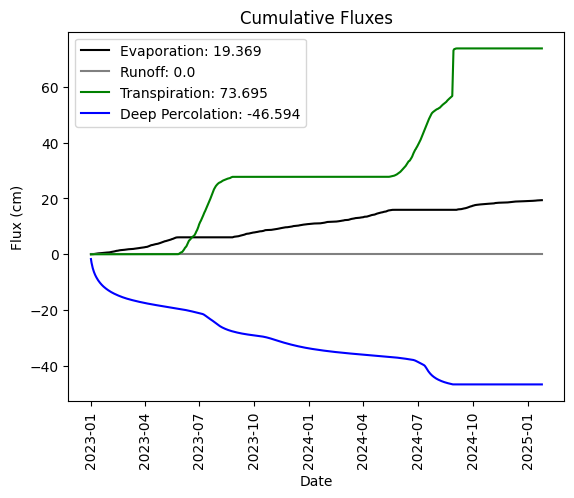

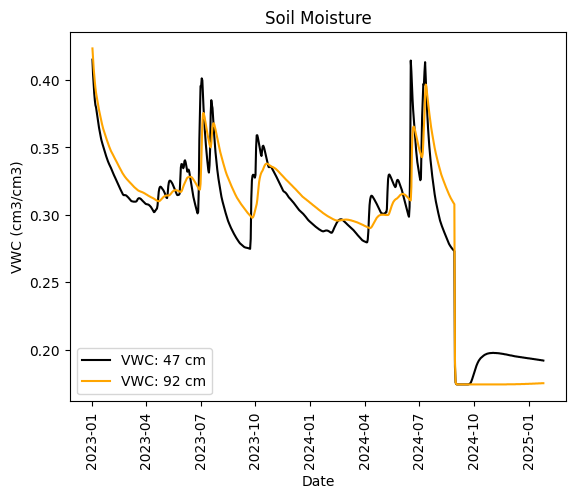

In [12]:
#Read in data and plot!
if ("FAILED.csv" in os.listdir(os.path.join(main_level, '3_Results', newfolder))) == False:
    
    #read in t level and obs node data
    tlevel = ml.read_tlevel_modified(usecols= ['Time','rTop', 'rRoot', 'vTop', 'vRoot', 'vBot', 'sum(rTop)', 'sum(rRoot)', 'sum(vTop)',
'sum(vRoot)', 'sum(vBot)', 'hTop', 'hRoot', 'hBot', 'RunOff', 'sum(RunOff)', 'Volume', 'sum(Infil)', 'sum(Evap)', 'Cum(WTrans)'])
    obsnode = ml.read_obs_node()

    #make obs node data into a dataframe
    allobs = pd.DataFrame()
    
    for i in range(len(obslist)):
       nodenum = obslist[i]*-1+1
       obstemp =obsnode[nodenum]
       obstemp= obstemp.rename(columns={'h':f"h{nodenum}",
                             'theta':f"theta{nodenum}",
                             'Temp':f"temp{nodenum}"})
       allobs = pd.concat([allobs, obstemp], axis=1)

    #merge data to create csv file
    output = pd.concat([tlevel, allobs], axis=1)
    outputr = output.reset_index(drop=True)
    alldata = pd.concat([atm, outputr], axis= 1)


    alldata.to_csv(os.path.join(main_level, '3_Results', newfolder, 'HydrusMergedData.csv'))
    
    #make a new folder for plots to fill
    if not os.path.exists(os.path.join(main_level, '3_Results', newfolder, 'Plots')):
        os.mkdir(os.path.join(main_level, '3_Results', newfolder, 'Plots'))

    #plot cumulative fluxes
    xs= alldata['Date']
    
    from datetime import datetime
    xs = pd.to_datetime(xs)
    y1 = alldata['sum(Evap)']
    y2= alldata['sum(RunOff)']
    y3= alldata['sum(vRoot)']
    y4= alldata['sum(vBot)']
    
    #get maxes to include on plot
    emax = max(alldata['sum(Evap)'])
    tmax = max(alldata['sum(vRoot)'])
    dmax = min(alldata['sum(vBot)'])
    rmax = max(alldata['sum(RunOff)'])
    
    #plt.plot(xs, y1, xs, y2, xs, y3, xs, y4)
    plt.plot(xs, y1, label= f"Evaporation: {emax}", c= "black")
    plt.plot(xs, y2, label= f"Runoff: {rmax}", c= "gray")
    plt.plot(xs, y3, label= f"Transpiration: {tmax}", c= "green")
    plt.plot(xs, y4, label= f"Deep Percolation: {dmax}", c= "blue")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Flux (cm)")
    plt.title("Cumulative Fluxes")
    plt.xticks(rotation= 90)
    
    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'CumulativeFluxes.png'))
    plt.show()
    #plot soil moisture at specified depths
    y1 = alldata['theta47']
    y2= alldata['theta92']
    
    plt.plot(xs, y1, label= "VWC: 47 cm", c= "black")
    plt.plot(xs, y2, label= "VWC: 92 cm", c= "orange")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("VWC (cm3/cm3)")
    plt.title("Soil Moisture")
    plt.xticks(rotation= 90)

    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'SoilMoisture.png'))
    plt.show()
    



In [13]:
#Re-running with different root data, to make sure it works as expected
exe = os.path.join(os.getcwd(), "H1D_CALC.EXE")
newfolder = 'RootsGDD'
ws = os.path.join(main_level, '3_Results', newfolder)

#Atmospheric Input
days = len(atm4b['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', 'IrrigationData.csv'))
irrigation['Date'] = pd.to_datetime(irrigation['Date'])

#merge weather and irrigation and add for a total water input column
allatm = atm4b.join(irrigation.set_index('Date'), on='Date')
allatm.loc[np.isnan(allatm['Amount_cm']) == True, 'Amount_cm'] = 0
allatm['WaterIn_cm'] = allatm['Precip'] + allatm['Amount_cm']

#create new dataframe to manipulate to be exactly what is needed for PHydrus (keeping old version w/ temperature info for now)
atm_hydrus = allatm[['WaterIn_cm', 'pot_e_cm', 'pot_t_cm', 'RootDepth']]

#these are required column names: 'tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT'
atm_hydrus = atm_hydrus.rename(columns={'pot_e_cm':'rSoil', 'WaterIn_cm':'Prec', 'pot_t_cm': 'rRoot'}) #rename columns that are there
atm_hydrus['tAtm'] = range(1,len(atm2)+1)
atm_hydrus['hCritA']= 1000000 #max allowed surface head, this is hydrus default
atm_hydrus['rB']= 0 #bottom flux, is zero for free drainage boundary condition
atm_hydrus['hB']= 0 #groundwater level, is zero if model is not being run with groundwater
atm_hydrus['hT']= 0 #surface pressure head, zero if model uses free drainage

#rearrange to match format input
atm_hydrus = atm_hydrus[['tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT', 'RootDepth']]
atm_hydrus.loc[np.isnan(atm_hydrus['RootDepth']) == True, 'RootDepth'] = 0


In [14]:
#Run Hydrus with new inputs

for i in range(len(timesteps2)):
    #basic model info (name, units)
    ml = Model(exe_name=exe, #telling it to use single porosity exe
              ws_name=ws, #folder to create/fill (in 3_Results)
              name="model",
              mass_units="mmol", time_unit="days", length_unit="cm")
    #add time info
    times = ml.add_time_info(tinit=0, #first day
                         tmax=days, #last day
                         print_times=True, #true if want model to print t level info every day
                        # printinit= 1,
                         #printmax= 40,
                         #dtprint= 1,
                         dt=timesteps2[i], #initial time increment (this is what R iteratres through)
                         dtmax=0.5, #max time increment (didn't change)
                         #printinit=120 #this would specify when to start printing t level info
                        )
    
    #add waterflow information for selector on model type, boundary conditions, can add groundwater here (didn't)
    ml.add_waterflow(model= 0, #single porosity
                 top_bc=3, #top boundary condition is atmospheric with runoff
                 bot_bc=4, #bottom boundary condition is free drainage
                 )
    
    #this is a dataframe for soil materials, n=1 is number of materials
    m = ml.get_empty_material_df_modified(n=1)
    
    #these are vg parameters for each depth
    m.loc[1] = vglist1[0:6]
    

    #add materials to function
    ml.add_material(m)
    
    #create soil profile
    profile = pl.create_profile(bot= -150, #depth of soil profile
                                dx= 1, #grid cells 1 cm
                                h=-15 #intial pressure head
                                )
    
    #profile.loc[75:100, "Mat"] = 2 #depth to start second soil material
    #profile.loc[101:150, "Mat"] = 3
        #add  profile to model
    ml.add_profile_modified(profile)
    
    #observations nodes
    ml.add_obs_nodes(obslist)
    
    poptms= [-1]
    ml.add_root_uptake(model= 0, #feddes water uptake
                   p0= -1, #pressure head below which roots can extract water from soil
                   p2h= -500, #pressure head below which roots cannot extract water at maximum rate
                   p2l= -900, #manual says same as p2h exceot with potential transpiration of 'r2L'
                   p3= -1600, #wilting point: no root water extraction
                   r2h= 0.5,
                   r2l= 0.1,
                   poptm= poptms, #pressure head below which roots extract water at max rate, 1 per soil type
                   pexp= 3, #exponent for stress response function, accepting default of 3
                   crootmax= 1 #this is max concentration of solute for root uptake, this model doesn't have solutes but isn't working without
                   )
    
    #make table of root data
    ml.add_root_growth(irootin= 1, #roots are a table
                       ngrowth= len(atm_hydrus), #number of data points
                       tgrowth= atm_hydrus['tAtm'], #days
                       rootdepth= atm_hydrus['RootDepth'] #root depths
                       )
  
    '''
    ml.add_root_growth(irootin= 2,
                       irfak= 0, #root growth is calculated from given data
                       trmin= 1, #day when roots start growing
                       trmed= 150, #time of a specific root growth benchmark
                       trmax= 365, #end of root growth period
                       xrmin= 20, #root depth at start of growth period
                       xrmed= 25, #root depth at trmed time
                       xrmax= 30, #max rooting depth
                       trperiod= 365 #number of days in root growth cycle
                       )
    '''
    #add atmosphere input to Hydrus
    ml.add_atmospheric_bc(atm_hydrus)
    
    #write out input files
    ml.write_input_modified()
    
    #run Hydrus!
    rs = ml.simulate()

    #check if model ran completely
    #first step: read in output
    tlevel = ml.read_tlevel_modified()

    #check that output length equals input length, if TRUE stop loop, if FALSE keep going
    if len(tlevel) == days:
       # ml.plots.profile()
        break
    else:
        if i == len(timesteps2)-1:
            failed = pd.DataFrame()
            failed.to_csv(os.path.join(main_level, '3_Results', newfolder, 'FAILED.csv'))


c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\EditedFunctions260112mr.py:504: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 4.2670e-01
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 6.8000e-02 3.2300e-02 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 6.1200e-02 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 2.3290e-01 1.7660e-01 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 1.7000e-03 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 2.4650e-01 0.0000e+00
 0.0000e+00 0.00

c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:198: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = read_csv(file, skiprows=s, nrows=e - s - 2, usecols=usecols,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:203: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.drop(index=data.index[0]).apply(to_numeric,
c:\Users\meghanrobinson\Downloads\Modeling\PHydrusTest\Hydrus\PHydrusRootsEdited_26-01-05\2_Code\ReadFunction.py:243: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1

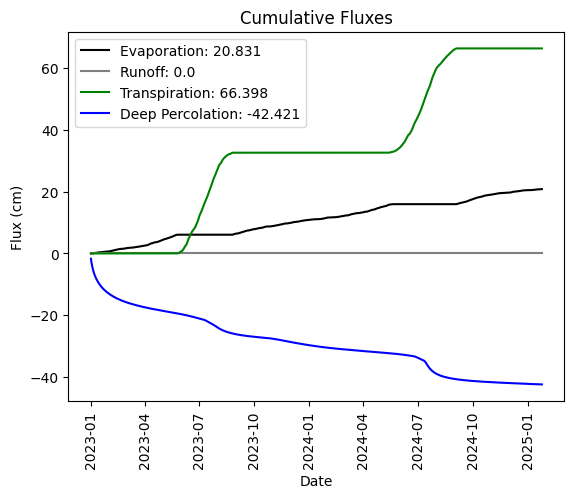

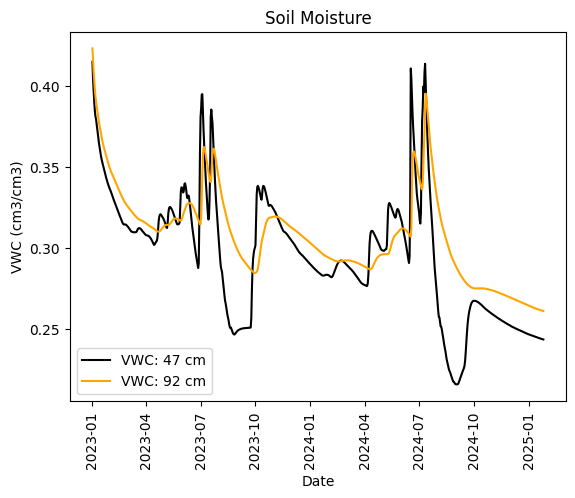

In [15]:
#Read in data and plot!
if ("FAILED.csv" in os.listdir(os.path.join(main_level, '3_Results', newfolder))) == False:
    
    #read in t level and obs node data
    tlevel = ml.read_tlevel_modified(usecols= ['Time','rTop', 'rRoot', 'vTop', 'vRoot', 'vBot', 'sum(rTop)', 'sum(rRoot)', 'sum(vTop)',
'sum(vRoot)', 'sum(vBot)', 'hTop', 'hRoot', 'hBot', 'RunOff', 'sum(RunOff)', 'Volume', 'sum(Infil)', 'sum(Evap)', 'Cum(WTrans)'])
    obsnode = ml.read_obs_node()

    #make obs node data into a dataframe
    allobs = pd.DataFrame()
    
    for i in range(len(obslist)):
       nodenum = obslist[i]*-1+1
       obstemp =obsnode[nodenum]
       obstemp= obstemp.rename(columns={'h':f"h{nodenum}",
                             'theta':f"theta{nodenum}",
                             'Temp':f"temp{nodenum}"})
       allobs = pd.concat([allobs, obstemp], axis=1)

    #merge data to create csv file
    output = pd.concat([tlevel, allobs], axis=1)
    outputr = output.reset_index(drop=True)
    alldata = pd.concat([atm, outputr], axis= 1)


    alldata.to_csv(os.path.join(main_level, '3_Results', newfolder, 'HydrusMergedData.csv'))
    
    #make a new folder for plots to fill
    if not os.path.exists(os.path.join(main_level, '3_Results', newfolder, 'Plots')):
        os.mkdir(os.path.join(main_level, '3_Results', newfolder, 'Plots'))

    #plot cumulative fluxes
    xs= alldata['Date']
    
    from datetime import datetime
    xs = pd.to_datetime(xs)
    y1 = alldata['sum(Evap)']
    y2= alldata['sum(RunOff)']
    y3= alldata['sum(vRoot)']
    y4= alldata['sum(vBot)']
    
    #get maxes to include on plot
    emax = max(alldata['sum(Evap)'])
    tmax = max(alldata['sum(vRoot)'])
    dmax = min(alldata['sum(vBot)'])
    rmax = max(alldata['sum(RunOff)'])
    
    #plt.plot(xs, y1, xs, y2, xs, y3, xs, y4)
    plt.plot(xs, y1, label= f"Evaporation: {emax}", c= "black")
    plt.plot(xs, y2, label= f"Runoff: {rmax}", c= "gray")
    plt.plot(xs, y3, label= f"Transpiration: {tmax}", c= "green")
    plt.plot(xs, y4, label= f"Deep Percolation: {dmax}", c= "blue")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Flux (cm)")
    plt.title("Cumulative Fluxes")
    plt.xticks(rotation= 90)
    
    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'CumulativeFluxes.png'))
    plt.show()
    #plot soil moisture at specified depths
    y1 = alldata['theta47']
    y2= alldata['theta92']
    
    plt.plot(xs, y1, label= "VWC: 47 cm", c= "black")
    plt.plot(xs, y2, label= "VWC: 92 cm", c= "orange")
    
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("VWC (cm3/cm3)")
    plt.title("Soil Moisture")
    plt.xticks(rotation= 90)

    plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'SoilMoisture.png'))
    plt.show()
    

